### Importando...

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split

from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from sklearn import model_selection
from keras.layers import Dense
from keras import regularizers
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical

### Análise exploratória dos dados

In [2]:
treino = pd.read_csv('treino.csv')
teste = pd.read_csv('teste.csv')

In [6]:
# Verificar valores nulos no dataset

print("Valores Nulos Treino:",treino.isnull().sum().sum(),"Valores Nulos Teste:",teste.isnull().sum().sum()  )

Valores Nulos Treino: 0 Valores Nulos Teste: 0


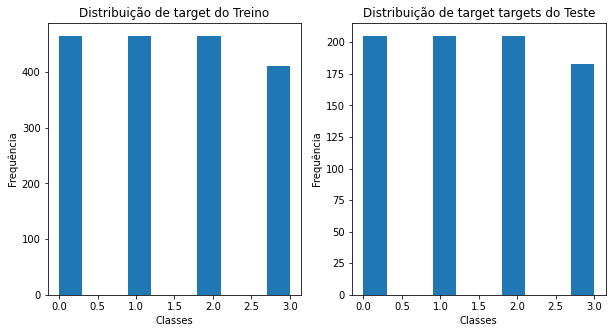

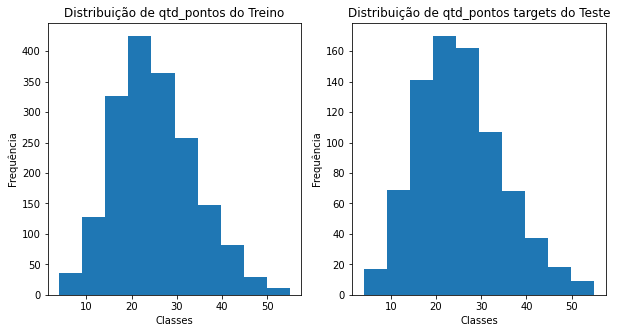

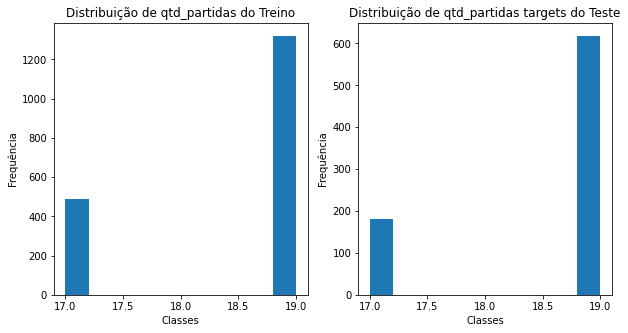

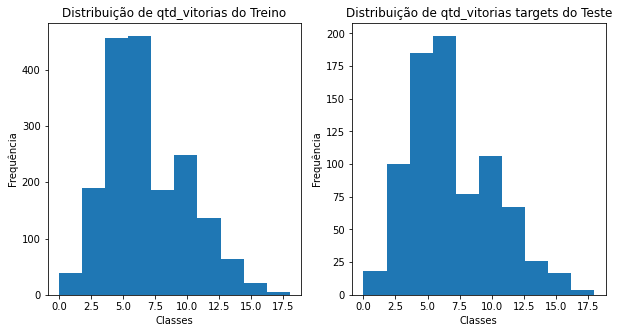

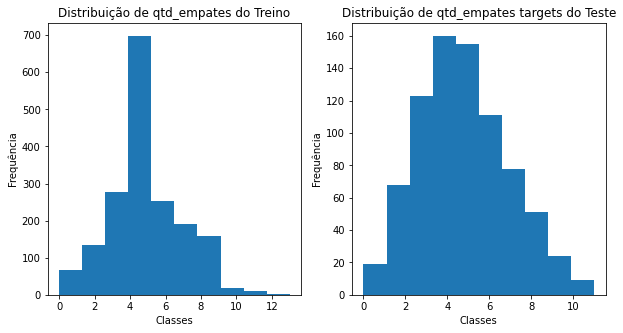

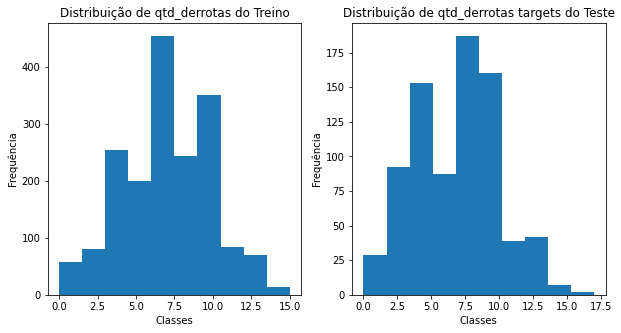

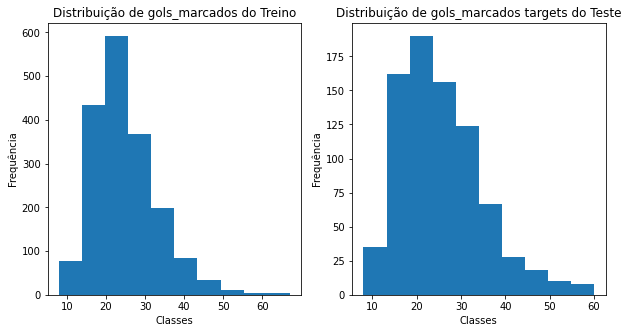

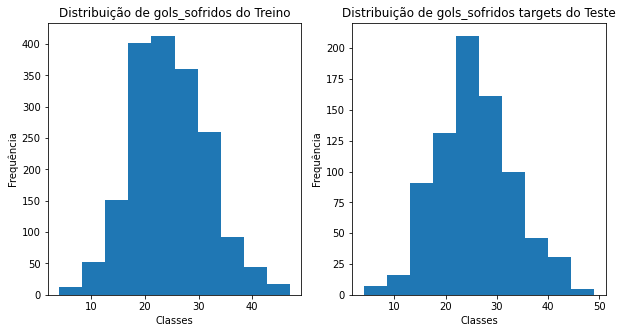

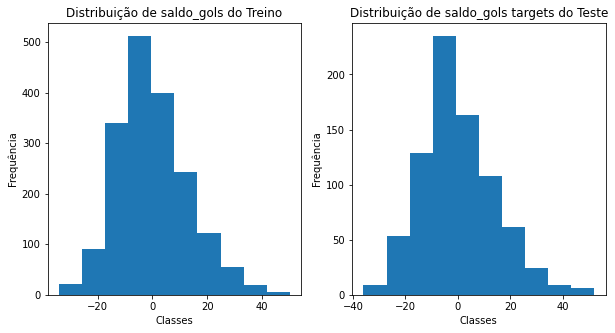

In [18]:
# indice 0 -  target, indice 1 qtd pontos, indice 2 qtd partidas, indice 3 qtd vitorias, indice 4 qtd empates, indice 5 qtd derrotas, indice 6 gols marcados, indice 7 gols sofridos, indice 8 saldo de gols
columNames = ['target','qtd_pontos','qtd_partidas','qtd_vitorias','qtd_empates','qtd_derrotas','gols_marcados','gols_sofridos','saldo_gols']

for i in range(len(columNames)):
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title(f'Distribuição de {columNames[i]} do Treino')
    plt.hist(treino[f'{i}'], bins=10)
    plt.xlabel('Classes')
    plt.ylabel('Frequência')

    plt.subplot(1,2,2)
    plt.title(f'Distribuição de {columNames[i]} targets do Teste')
    plt.hist(teste[f'{i}'], bins=10)
    plt.xlabel('Classes')
    plt.ylabel('Frequência')

    plt.show()  

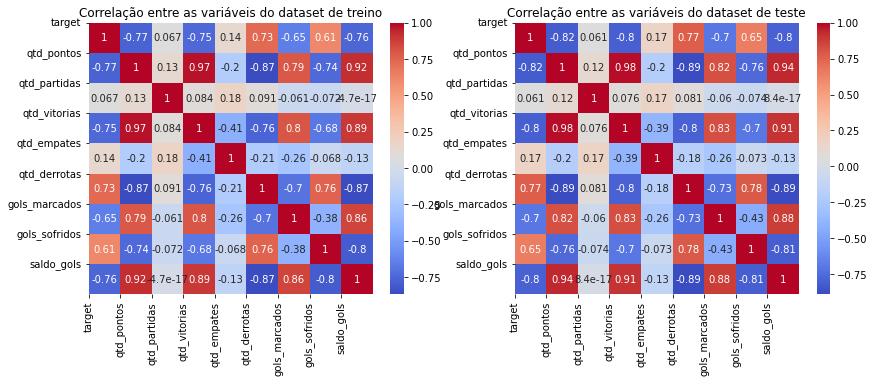

In [34]:
# heatmap

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.title('Correlação entre as variáveis do dataset de treino')
plt.xlabel('Variáveis')
plt.ylabel('Variáveis')


sns.heatmap(treino.corr(), annot=True, cmap='coolwarm')
#setar nome das colunas
plt.xticks(np.arange(9), columNames, rotation=90)
plt.yticks(np.arange(9), columNames, rotation=0)

plt.subplot(1,2,2)


plt.title('Correlação entre as variáveis do dataset de teste')
plt.xlabel('Variáveis')
plt.ylabel('Variáveis')


sns.heatmap(teste.corr(), annot=True, cmap='coolwarm')
#setar nome das colunas
plt.xticks(np.arange(9), columNames, rotation=90, fontsize=10)
plt.yticks(np.arange(9), columNames, rotation=0, fontsize=10)




plt.show()



In [19]:
teste.describe()

,0,1,2,3,4,5,6,7,8
count,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000,798.000000
mean,1.458647,25.384712,18.548872,6.854637,4.839599,6.854637,25.459900,25.459900,0.000000
std,1.105555,9.278684,0.836431,3.290063,1.980288,3.067852,9.260906,7.485512,14.211081
min,0.000000,4.000000,17.000000,0.000000,0.000000,0.000000,8.000000,4.000000,-36.000000
25%,0.000000,19.000000,19.000000,4.000000,3.000000,5.000000,19.000000,20.000000,-9.000000
50%,1.000000,25.000000,19.000000,6.000000,5.000000,7.000000,24.000000,25.000000,-2.000000
75%,2.000000,31.000000,19.000000,9.000000,6.000000,9.000000,30.000000,30.000000,8.000000
max,3.000000,55.000000,19.000000,18.000000,11.000000,17.000000,60.000000,49.000000,52.000000


In [20]:
treino.describe()

,0,1,2,3,4,5,6,7,8
count,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000,1806.000000,1806.0000
mean,1.455150,25.216501,18.461794,6.800664,4.860465,6.800664,24.624031,24.624031,0.0000
std,1.103976,8.641277,0.887233,3.080475,2.022428,2.856905,8.247881,7.053327,12.7398
min,0.000000,4.000000,17.000000,0.000000,0.000000,0.000000,8.000000,4.000000,-34.0000
25%,0.000000,19.000000,17.000000,5.000000,3.000000,5.000000,19.000000,20.000000,-8.0000
50%,1.000000,24.000000,19.000000,6.000000,5.000000,7.000000,23.000000,24.000000,-1.0000
75%,2.000000,31.000000,19.000000,9.000000,6.000000,9.000000,29.000000,29.000000,7.0000
max,3.000000,55.000000,19.000000,18.000000,13.000000,15.000000,67.000000,47.000000,50.0000


### Usando Arvore de decisão

In [99]:
# Dividir os dados em treino e teste

Y = treino['0']
X = treino.drop('0', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [100]:
tree = DecisionTreeClassifier(random_state=42, max_depth=3, min_samples_split=2, min_samples_leaf=1, max_features=None, criterion='gini')
tree.fit(X_train, y_train)

print('Ein: %0.4f' % (1 - accuracy_score(y_train, tree.predict(X_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, tree.predict(X_test))))
print(classification_report(y_test, tree.predict(X_test)))



Ein: 0.4169
Eout: 0.4475
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        87
           1       0.49      0.48      0.48        81
           2       0.42      0.70      0.52        96
           3       0.78      0.30      0.43        98

    accuracy                           0.55       362
   macro avg       0.62      0.56      0.55       362
weighted avg       0.62      0.55      0.55       362



In [101]:
treino.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8'], dtype='object')

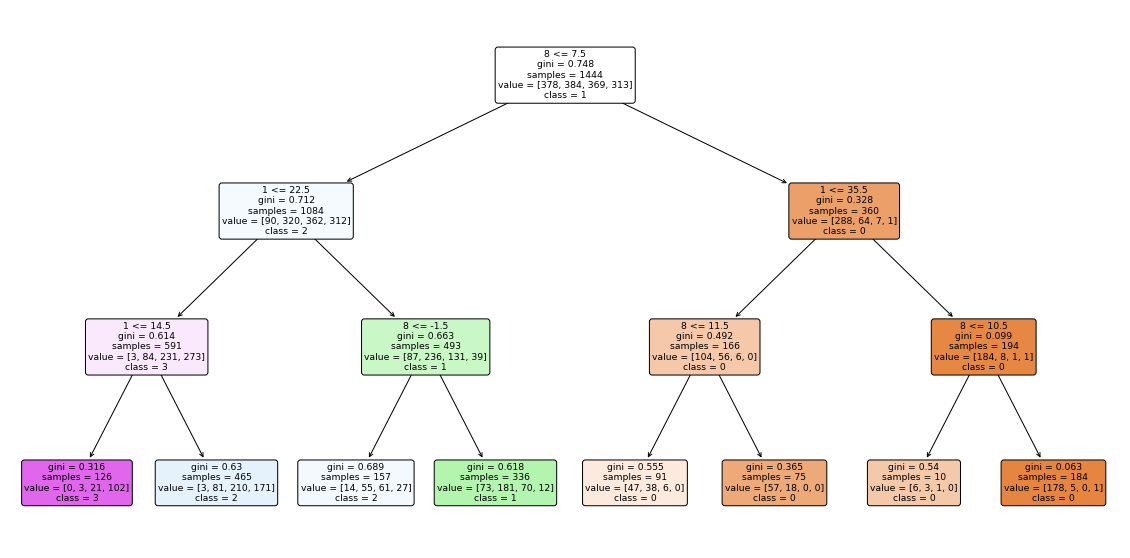

In [102]:
plt.figure(figsize=(20,10))
plot_tree(tree, filled=True,
          rounded=True,
          feature_names=treino.columns[1:],
          class_names=["0", "1", "2", "3"])
plt.show()

In [103]:
## altura da árvore tree
print('Altura da árvore: %d' % tree.get_depth())
## tamanho  
print('Número de nós: %d' % tree.get_n_leaves())


Altura da árvore: 3
Número de nós: 8


In [104]:
# Poda

ccp_path = tree.cost_complexity_pruning_path(X_train, y_train)
alphas = {'ccp_alpha': ccp_path.ccp_alphas}

new_tree = GridSearchCV(estimator=tree, param_grid=alphas, cv = 10)
new_tree.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
             param_grid={'ccp_alpha': array([0.        , 0.00144133, 0.00271011, 0.00762727, 0.01191417,
       0.02052924, 0.05674795, 0.13250526])})

In [105]:
new_tree.best_estimator_

DecisionTreeClassifier(ccp_alpha=0.01191417152173821, max_depth=3,
                       random_state=42)

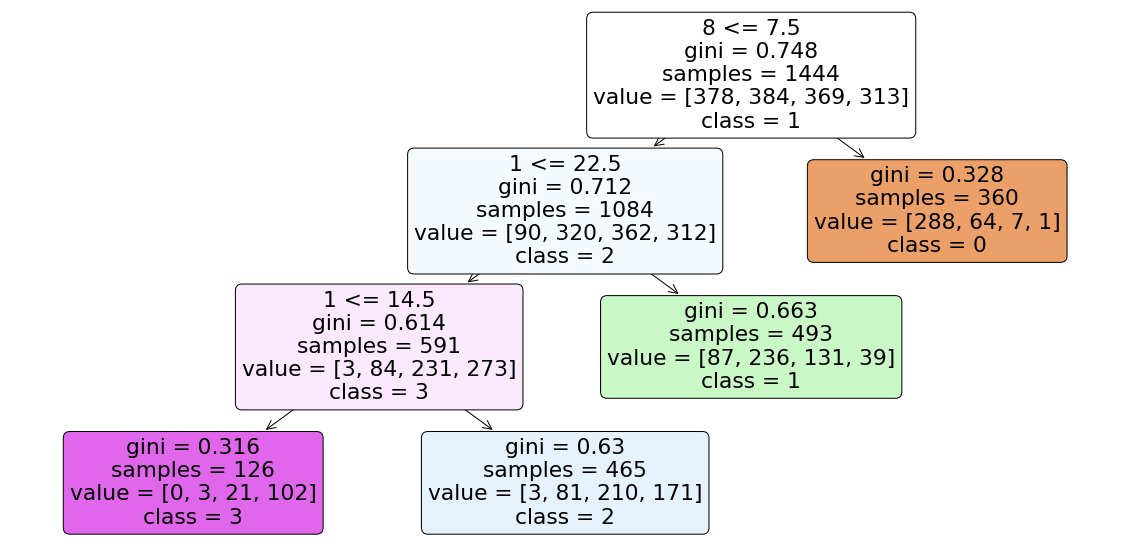

In [106]:
plt.figure(figsize=(20,10))
plot_tree(new_tree.best_estimator_,
          filled=True,
          rounded=True,
          feature_names=treino.columns[1:],
          class_names=["0", "1", "2", "3"])
plt.show()

In [107]:
print('Ein: %0.4f' % (1 - accuracy_score(y_train, new_tree.predict(X_train))))
print('Eout: %0.4f' % (1 - accuracy_score(y_test, new_tree.predict(X_test))))
print(classification_report(y_test, new_tree.predict(X_test)))

Ein: 0.4211
Eout: 0.4613
              precision    recall  f1-score   support

           0       0.77      0.75      0.76        87
           1       0.44      0.65      0.52        81
           2       0.40      0.50      0.44        96
           3       0.78      0.30      0.43        98

    accuracy                           0.54       362
   macro avg       0.60      0.55      0.54       362
weighted avg       0.60      0.54      0.53       362



### Usando Redes Neurais

In [112]:
data_normalizado = treino.copy()
for column in data_normalizado.columns[1:]:
    data_normalizado[column] = (data_normalizado[column] - data_normalizado[column].min()) / (data_normalizado[column].max() - data_normalizado[column].min())

display(data_normalizado)

,0,1,2,3,4,5,6,7,8
0,0,0.666667,1.0,0.611111,0.384615,0.200000,0.406780,0.395349,0.535714
1,0,0.588235,1.0,0.500000,0.538462,0.200000,0.322034,0.395349,0.476190
2,0,0.549020,1.0,0.500000,0.384615,0.333333,0.322034,0.302326,0.523810
3,0,0.529412,1.0,0.500000,0.307692,0.400000,0.457627,0.488372,0.523810
4,0,0.490196,1.0,0.444444,0.384615,0.400000,0.372881,0.511628,0.452381
...,...,...,...,...,...,...,...,...,...
1801,3,0.274510,1.0,0.222222,0.461538,0.600000,0.152542,0.418605,0.345238
1802,2,0.235294,1.0,0.222222,0.307692,0.733333,0.355932,0.720930,0.333333
1803,3,0.196078,1.0,0.222222,0.153846,0.866667,0.152542,0.720930,0.190476
1804,3,0.176471,1.0,0.166667,0.307692,0.800000,0.135593,0.860465,0.107143


In [120]:
X = data_normalizado.drop('0', axis=1)
y = data_normalizado['0']

In [121]:
X_train, X_val, y_train, y_val = model_selection.train_test_split(X_train, y_train, random_state=2, test_size=0.2)

In [116]:
# model = Sequential()
# model.add(Dense(70, input_dim=12, activation='relu'))
# model.add(Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.01)))
# model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])
# print(model.summary())

# es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20)
# history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200, batch_size=16, callbacks=[es])

1806

In [124]:
# Codificar os rótulos alvo em formato one-hot
y_train_one_hot = to_categorical(y_train)
y_val_one_hot = to_categorical(y_val)

# Inicializar o modelo
model = Sequential()

# Adicionar a camada de entrada
model.add(Dense(32, input_dim=8, activation='relu'))

# Adicionar as camadas ocultas
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))

# Adicionar a camada de saída
model.add(Dense(4, activation='softmax'))

# Compilar o modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Resumo do modelo
print(model.summary())

# Configurar parada antecipada (early stopping)
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=20)

# Treinar o modelo
history = model.fit(X_train, y_train_one_hot, validation_data=(X_val, y_val_one_hot), epochs=100, batch_size=32, callbacks=[es])

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 32)                288       
                                                                 
 dense_9 (Dense)             (None, 64)                2112      
                                                                 
 dense_10 (Dense)            (None, 64)                4160      
                                                                 
 dense_11 (Dense)            (None, 4)                 260       
                                                                 
Total params: 6,820
Trainable params: 6,820
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/100
29/29 [==============================] - 5s 56ms/step - loss: 1.4155 - accuracy: 0.4762 - val_loss: 0.9441 - val_accuracy: 0.6017
Epoch 2/100
29/29 [==================

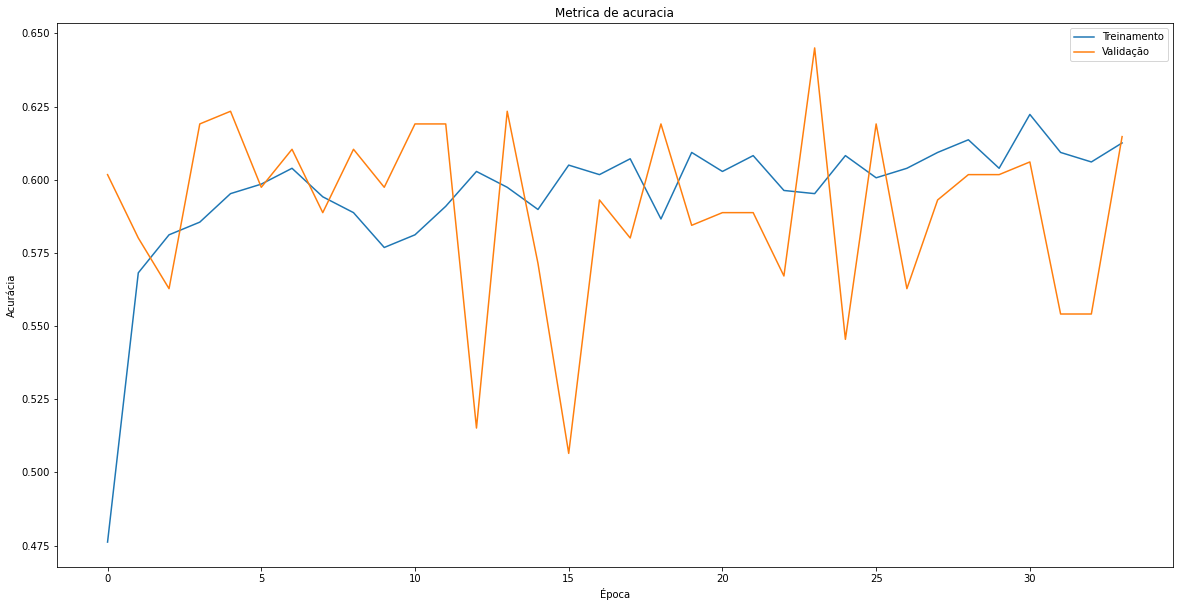

29/29 [==============================] - 0s 4ms/step

Acurácia (treinamento): 0.5097
Acurácia (validação): 0.4805


In [126]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Metrica de acuracia')
plt.ylabel('Acurácia')
plt.xlabel('Época')
plt.legend(['Treinamento', 'Validação'])
plt.rcParams["figure.figsize"] = (20,10)
plt.show()

pred = np.round(model.predict(X_val))
pred_train = np.round(model.predict(X_train))

# Calcular a acurácia usando a função accuracy_score
accuracy_train = accuracy_score(y_train_one_hot.argmax(axis=1), pred_train.argmax(axis=1))
accuracy_val = accuracy_score(y_val_one_hot.argmax(axis=1), pred.argmax(axis=1))
print(f'\nAcurácia (treinamento): {accuracy_train:.4f}')
print(f'Acurácia (validação): {accuracy_val:.4f}')


In [142]:
pred_test = np.round(model.predict(X_test))
pred_train = np.round(model.predict(X_train))

# Converter as previsões do modelo para formato multiclasse
pred_test_multiclass = np.argmax(pred_test, axis=1)
pred_train_multiclass = np.argmax(pred_train, axis=1)

# Calcular e imprimir as métricas de acurácia
print(f'Acurácia (treino): {accuracy_score(y_train, pred_train_multiclass):.4f}')
print(f'Acurácia (teste): {accuracy_score(y_test, pred_test_multiclass):.4f}')

# Calcular e imprimir as taxas de erro
print(f'Ein: {1-accuracy_score(y_train, pred_train_multiclass):.4f}') 
print(f'Eout: {1-accuracy_score(y_test, pred_test_multiclass):.4f}')

# Imprimir o relatório de classificação
print('\nRelatório de Classificação:')
print(classification_report(y_test, pred_test_multiclass))


29/29 [==============================] - 0s 4ms/step
Acurácia (treino): 0.5097
Acurácia (teste): 0.4696
Ein: 0.4903
Eout: 0.5304

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.38      0.77      0.51        87
           1       0.49      0.60      0.54        81
           2       0.49      0.22      0.30        96
           3       0.80      0.34      0.47        98

    accuracy                           0.47       362
   macro avg       0.54      0.48      0.46       362
weighted avg       0.55      0.47      0.45       362

